In [1]:
!pip install -U kagglehub

In [2]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
paultimothymooney_chest_xray_pneumonia_path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')

print('Data source import complete.')

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Data source import complete.


In [3]:
# installs in case environment doesn't have needed packages
!pip install pillow pandas numpy matplotlib seaborn torch --quiet

In [4]:
import os
from PIL import Image

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import random_split, DataLoader, Dataset

import random
import warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')

SEED = 42

### Notation for working on this Notebook (Remove before event)
- TODO: means anything that the presenter should implement.
- NOTE: this is meant for whoever is working on this notebook. This is just clarification for what is going on in the code as well as comments on how this should and can be changed.
- FOR STUDENTS: anything that students should implement during the workshop. Ideally a completed version of the code with the implementation of these functions should be provided.

For comments and markdown, anything can be changed to give further description or to better explain concepts.  
In general, this event is expected to be fairly qualitative as there is a large variation in background knowledge for the subject in the audience.

In [5]:
print(paultimothymooney_chest_xray_pneumonia_path)

/kaggle/input/chest-xray-pneumonia


In [6]:
os.listdir("/kaggle/input/chest-xray-pneumonia")

['chest_xray']

In [7]:
os.listdir("/kaggle/input/chest-xray-pneumonia/chest_xray")

['chest_xray', '__MACOSX', 'val', 'test', 'train']

In [8]:
os.listdir("/kaggle/input/chest-xray-pneumonia/chest_xray/train")

['PNEUMONIA', 'NORMAL']

In [9]:
# NOTE: This is just a skeleton for the actual notebook. The kaggle dataset presented
# here can be changed out for any other dataset that is deemed fit. The get data function
# will also have to be adjusted accordingly (or removed if applicable).
data_path = "/kaggle/input/chest-xray-pneumonia/chest_xray/train/"

def get_data(folder_path, image_size=(128, 128), sample_fraction=0.5) -> pd.DataFrame:
    """
    Returns dataframe with the images and labels.

    folder_path: path to folder containing 'Normal' and 'Target' subfolders
    image_size: shape of resized images
    """
    # NOTE: this assumes the folder with the data has subfolders for when the target is present
    # or when the target is not present
    data = []

    for label in os.listdir(folder_path):
        label_path = os.path.join(folder_path, label)
        if not os.path.isdir(label_path):
            continue

        files = [f for f in os.listdir(label_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        # Randomly sample a fraction of the files
        n_sample = max(1, int(len(files) * sample_fraction))
        sampled_files = random.sample(files, n_sample)

        for file in tqdm(sampled_files, desc=f"Reading from {label}"):
            img_path = os.path.join(label_path, file)
            img = Image.open(img_path).convert('RGB')
            img = img.resize(image_size)
            img_array = np.array(img)
            data.append([img_array, label])

    df = pd.DataFrame(data, columns=['image', 'label'])
    return df

df = get_data(data_path)

Reading from NORMAL: 100%|██████████| 670/670 [00:33<00:00, 19.95it/s]


In [10]:
def plot_image(df, index):
    """
    Plots an image from the DataFrame at the given index.

    df: pandas DataFrame containing 'image' and 'label' columns
    index: index of the image to plot
    """
    if index < 0 or index >= len(df):
        print("Index out of range")
        return

    img = df.iloc[index]['image']
    label = df.iloc[index]['label']

    plt.imshow(img)
    plt.title(f"Label: {label}")
    plt.axis('off')
    plt.show()

# Data
**NOTE:** This is very bare bones description since it is uncertain whether this dataset will be the final dataset. Any further exploration of the data especially as it is standard in medical imaging is greatly welcomed. This part is expected to take ~15-30 minutes.
## About the Data
The data in df contains images of Xray data for when pneumonia is or is not present.

**image**: The representation of the image as a numpy array with shape (128, 128, 3) ie. 128 pixels x 128 pixels with 3 channels for rgb in each pixel.

**label**: the label for whether or not the individual has pneumonia.

In [11]:
print("First Few Rows of Data")
display(df.head())
print("\n")

print("Metadata for Data")
display(df.info())

First Few Rows of Data


,image,label
0,"[[[44, 44, 44], [47, 47, 47], [49, 49, 49], [4...",PNEUMONIA
1,"[[[185, 185, 185], [191, 191, 191], [188, 188,...",PNEUMONIA
2,"[[[144, 144, 144], [146, 146, 146], [148, 148,...",PNEUMONIA
3,"[[[28, 28, 28], [168, 168, 168], [13, 13, 13],...",PNEUMONIA
4,"[[[43, 43, 43], [58, 58, 58], [75, 75, 75], [7...",PNEUMONIA




Metadata for Data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2607 entries, 0 to 2606
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   2607 non-null   object
 1   label   2607 non-null   object
dtypes: object(2)
memory usage: 40.9+ KB


None

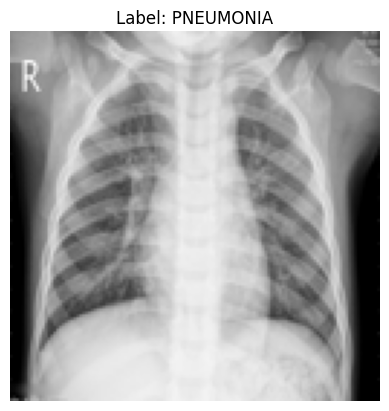

In [12]:
# Sample image from the data
plot_image(df, 2)

In [13]:
# TODO: Any additional exploratory data analysis is welcome for helping people better
# understand what is going on. Generally we expect our audience to be fairly
# new to the topics presented but there are some people who want a deeper understanding
# of the data.

# Model Building
**NOTE:** The description of algorithms used is not expected to be too in depth. Any additional explanation for how things work is very appreciated. Depending on how technical the explanations of what is going on are, this section should take ~20-30 minutes.

## Neural Networks
**TODO:** Provide a brief explaination of what is a neural network and when they are used. This doesn't have to be too technical, just enough for the audience to get a general idea of what they are working with.

## Convolutional Neural Networks
**TODO:** Just a brief intuitive description of how CNNs work and/or when/why they are typically used. A description of workings can be omitted if that is deemed necessary.

### Further (and more Mathy) resources on CNN's and Neural Networks:
3Blue1Brown playlist for Deep Learning -just a Generally Good place to start for Neural Networks: https://www.youtube.com/watch?v=aircAruvnKk&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi

Stanford CS230 CNN Cheatsheet - Good for general intuition of CNNs: https://web.stanford.edu/~shervine/teaching/cs-230/cheatsheet-convolutional-neural-networks/  

In [14]:
# Baseline CNN
# NOTE: This is just a very simple model, we don't expect a super in depth explanation for
# the neural network architecture.
class CNN(nn.Module):
    def __init__(self, num_classes=2):
        super(CNN, self).__init__()
        # Convolutional layers
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        # Pooling layer
        self.pool = nn.MaxPool2d(2, 2)

        # Fully connected layers
        self.fc1 = nn.Linear(64 * 16 * 16, 128)  # 128*128
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 128 -> 64
        x = self.pool(F.relu(self.conv2(x)))  # 64 -> 32
        x = self.pool(F.relu(self.conv3(x)))  # 32 -> 16
        x = x.view(x.size(0), -1)             # flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)                       # output logits
        return x

In [15]:
class ImageData(Dataset):
    # Pytorch Wrapper for Dataset
    def __init__(self, dataframe):
        """
        Args:
            dataframe: pandas dataframe with images and labels
        """
        self.dataframe = dataframe.reset_index(drop=True)
        labels = sorted(dataframe['label'].unique())
        self.label_map = {label: idx for idx, label in enumerate(labels)}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Get the image and label
        img = self.dataframe.loc[idx, 'image']
        img = np.transpose(img, (2, 0, 1))
        label_str = self.dataframe.loc[idx, 'label']
        label = self.label_map[label_str]

        img = torch.tensor(img, dtype=torch.float32)

        return img, label

In [16]:
# Hyperparams
LEARNING_RATE = 0.001
EPOCHS = 10

In [17]:
# Training
# NOTE: The training loop is also very basic as it is not too likely many people will
# understand the explanations for different parameters in the training loop.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
dataset = ImageData(df)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

for epoch in tqdm(range(EPOCHS)):
    model.train()
    total_loss = 0.0
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Training Loss: {total_loss/len(dataloader):.4f}")

 10%|█         | 1/10 [00:40<06:03, 40.37s/it]

Epoch 1, Training Loss: 2.4171


 20%|██        | 2/10 [01:14<04:54, 36.87s/it]

Epoch 2, Training Loss: 0.2330


 30%|███       | 3/10 [01:49<04:10, 35.75s/it]

...

Epoch 8, Training Loss: 0.0337


 90%|█████████ | 9/10 [05:14<00:34, 34.54s/it]

Epoch 9, Training Loss: 0.0306


100%|██████████| 10/10 [05:50<00:00, 35.04s/it]

Epoch 10, Training Loss: 0.0140


# Evaluation

**TODO:** Go over any metrics that should be discussed and especially what metrics are used in practice. This is likely to be the bulk of the workshop along with the model building. This section should take ~30-45 minutes.